In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as ticker

from pathlib import Path
from itertools import product

In [14]:
data_path = Path(os.getcwd()) / "Data-processing/Results/Omar/"

data = pd.read_csv(data_path / "01-data-damBreakNoVelocity.csv")
time = pd.read_csv(data_path / "02-time-damBreakNoVelocity.csv")
profile = pd.read_csv(data_path / "03-u_profile-damBreakNoVelocity.csv", low_memory=False)
error = pd.read_csv(data_path / "04-error-damBreakNoVelocity.csv")

# Tools

In [19]:
index_columns = set(time.columns[0:-1])
quantity_columns = [
            set(data.columns) - index_columns, 
            set(time.columns) - index_columns,
            set(error.columns) - index_columns
        ]
index_columns = list(index_columns)
quantity_columns = [sorted(list(i)) for i in quantity_columns]
print(index_columns)
print(quantity_columns)

color_list = ['#ffd700', '#0000ff', '#ea5f94', '#ffb14e', '#fa8775','#009E73']
# color_blind_colors = ['#56B4E9', '#D55E00', '#009E73', '#CC79A7', '#E69F00']
marker_options = [".", "s", "o", "*"]

# color_map = {res: color_list[i % len(color_list)] for i, res in enumerate(resolution_list)}
# marker_map = {error: marker_options[i % len(marker_options)] for i, error in enumerate(error_types)}

['Plant Height', 'Plant Density', 'Initial Condition', 'Order', 'Resolution']
[['Average Velocity', 'Moment 1', 'Moment 2', 'Moment 3', 'Moment 4', 'Moment 5', 'Moment 6', 'Water Height', 'x position'], ['Time'], ['Average Velocity', 'Error Type', 'U profile', 'Water Height', 'std U profile']]


# Numerical convergence

In [81]:
def create_legend_order_vs_error(fig):
    """ 
    Creates a single legend where it specifies:
        - What marker is associated to L2 norm and LInf
        - What color is linked to what resolution
    """
    marker_handles = []
    for error_type, marker in marker_map.items():
        handle = mlines.Line2D( [], [],
                                marker=marker,
                                markersize=8, color='black',
                                label=error_type.strip()
                            )
        marker_handles.append(handle)

    color_handles = []
    for res, color in color_map.items():
        handle = mpatches.Patch(color=color, label=f"Res = {int(res)}")
        color_handles.append(handle)

    # A blank line as a spacer
    blank = mlines.Line2D([], [], color='none', label='')  

    fig.legend(
        handles=[
            mlines.Line2D([], [], color='none', label='Error type'),   # header
            *marker_handles,
            blank,                                                       
            mlines.Line2D([], [], color='none', label='Resolution'),    # header
            *color_handles,
        ],
        loc='center left',    # places legend to the right of all subplots
        bbox_to_anchor = (1.0, 0.5),
        frameon=True,
        fontsize=11,
        handlelength=2.5,)

In [ ]:
# convergence quantities have resolution 1e4
mask_conv = error["Resolution"] == 10000
idx_conv = error.loc[mask_conv].index
idx_conv

TypeError: 'Index' object is not callable

In [66]:
for resolution in [1000, 2000, 5000, 10000]:   
    mask = (errors["Plant Height"] == 1.0) & (errors["Resolution"] == resolution) & (errors["Order"] == 5)
    print(errors.loc[mask, "L2 Average Velocity"].values)


[5.43567582e-06]
[1.4375914e-05]
[4.48083937e-06]
[1.87468767e-06]


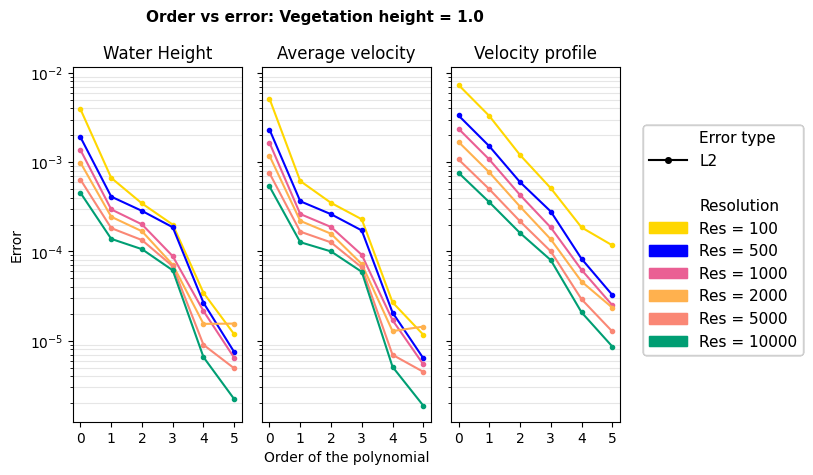

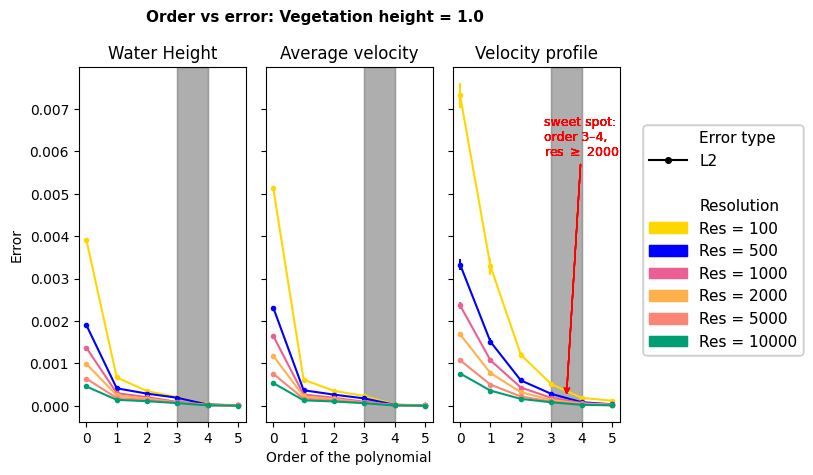

In [91]:
# Single plot
for height in plant_h_list:

    fig, axs = plt.subplots(1, 3, sharey=True)

    for resolution in resolution_list:

        mask = (errors["Plant Height"] == height) & (errors["Resolution"] == resolution)
        
        for error_type in error_types:

            axs[0].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Water Height"],
                        linestyle='-',
                        color=color_map[resolution],
                        marker=marker_map[error_type])

            axs[1].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Average Velocity"],
                        linestyle='-',
                        color=color_map[resolution],
                        marker=marker_map[error_type])

            axs[2].errorbar(errors.loc[mask,"Order"], errors.loc[mask, error_type+"U profile"],
                            yerr=errors.loc[mask, "L2 std U profile"],
                            color=color_map[resolution], 
                            marker=marker_map[error_type])

        axs[0].set_title("Water Height")
        axs[1].set_title("Average velocity")
        axs[2].set_title("Velocity profile")
        axs[0].set_ylabel("Error")
        axs[1].set_xlabel("Order of the polynomial")

        for ax in axs.flatten():
            ax.set_yscale("log")
            # ax.set_ylim(2e-6,7e-1)
            ax.grid()
            ax.grid(which="minor", color="0.9")
            ax.set_xticks(range(0,6))

        create_legend_order_vs_error(fig)
        fig.suptitle(rf"Order vs error: Vegetation height = {height}", fontsize=11, fontweight='bold')
        fig.tight_layout()
plt.show()

for height in plant_h_list:

    fig, axs = plt.subplots(1, 3, sharey=True)

    for resolution in resolution_list:

        mask = (errors["Plant Height"] == height) & (errors["Resolution"] == resolution)
        
        for error_type in error_types:

            axs[0].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Water Height"],
                        linestyle='-',
                        color=color_map[resolution],
                        marker=marker_map[error_type])

            axs[1].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Average Velocity"],
                        linestyle='-',
                        color=color_map[resolution],
                        marker=marker_map[error_type])

            axs[2].errorbar(errors.loc[mask,"Order"], errors.loc[mask, error_type+"U profile"],
                            yerr=errors.loc[mask, "L2 std U profile"],
                            color=color_map[resolution], 
                            marker=marker_map[error_type])

            print()      

        axs[0].set_title("Water Height")
        axs[1].set_title("Average velocity")
        axs[2].set_title("Velocity profile")
        axs[0].set_ylabel("Error")
        axs[1].set_xlabel("Order of the polynomial")
        
        for ax in axs.flatten():
        # highlight the recommended order range
            ax.axvspan(3, 4, color='grey', alpha=0.15, zorder=0)

        # annotate just once, on the most important panel (e.g. velocity profile)
        axs[2].annotate(
            "sweet spot:\norder 3–4,\nres $\\geq$ 2000",
            xy=(3.5, 2e-4), xycoords='data',              # arrow tip: stays in data coords
            xytext=(0.55, 0.75), textcoords='axes fraction',  # text position: relative, doesn't affect scale
            fontsize=9, ha='left', color="red",
            arrowprops=dict(arrowstyle="->", color='red', lw=1),
            annotation_clip=False
        )
        
        for ax in axs.flatten():
            # ax.set_yscale("log")
            # ax.set_ylim(2e-6,7e-1)
            ax.grid()
            ax.grid(which="minor", color="0.9")
            ax.set_xticks(range(0,6))

        create_legend_order_vs_error(fig)
        fig.suptitle(rf"Order vs error: Vegetation height = {height}", fontsize=11, fontweight='bold')
        fig.tight_layout()
plt.show()

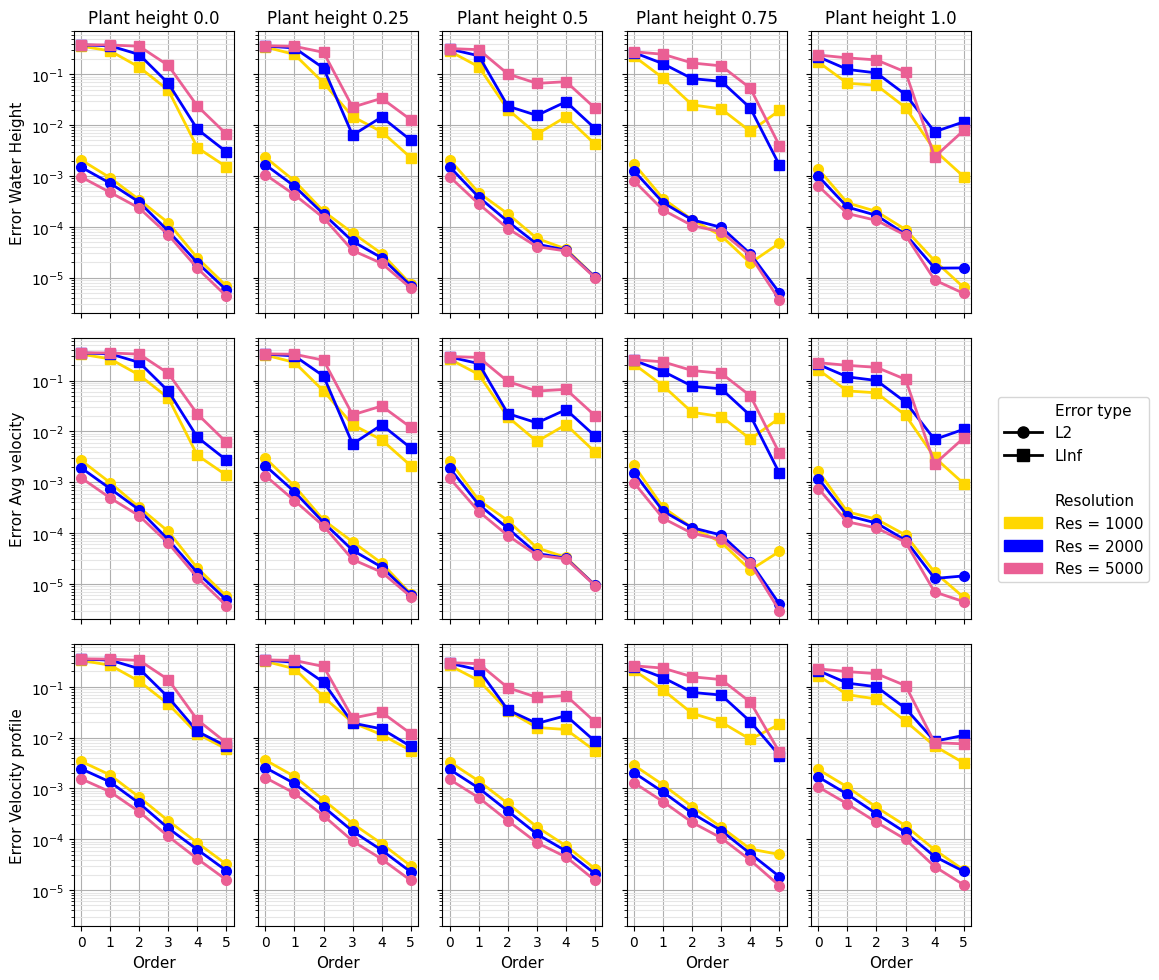

In [ ]:


############################    All in one plot     ############################
fig, axs = plt.subplots(3, 5, figsize=(10,10), sharex=True, sharey=True)

for i, height in enumerate(plant_h_list):

    for resolution in resolution_list:

        mask = (errors["Plant Height"] == height) & (errors["Resolution"] == resolution)
        
        for error_type in error_types:

            axs[0,i].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Water Height"],
                        linestyle='-',
                        color=color_map[resolution],
                        marker=marker_map[error_type])

            axs[1,i].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Average Velocity"],
                        linestyle='-',
                        color=color_map[resolution],
                        marker=marker_map[error_type])

            axs[2,i].errorbar(errors.loc[mask,"Order"], errors.loc[mask, error_type+"U profile"],
                            yerr=errors.loc[mask, "L2 std U profile"],
                            color=color_map[resolution], 
                            marker=marker_map[error_type])

for ax,h in zip(axs[0,:],plant_h_list): ax.set_title(f"Plant height {h}")
axs[0,0].set_ylabel("Error Water Height")
axs[1,0].set_ylabel("Error Avg velocity")
axs[2,0].set_ylabel("Error Velocity profile")
for ax in axs[-1,:]: ax.set_xlabel("Order")


for ax in axs.flatten():
    ax.set_yscale("log")
    ax.grid()
    ax.grid(which="minor", color="0.9")
    ax.set_ylim(2e-6,7e-1)
    ax.set_xticks(range(0,6))
create_legend_order_vs_error(fig)
fig.tight_layout()
plt.show()

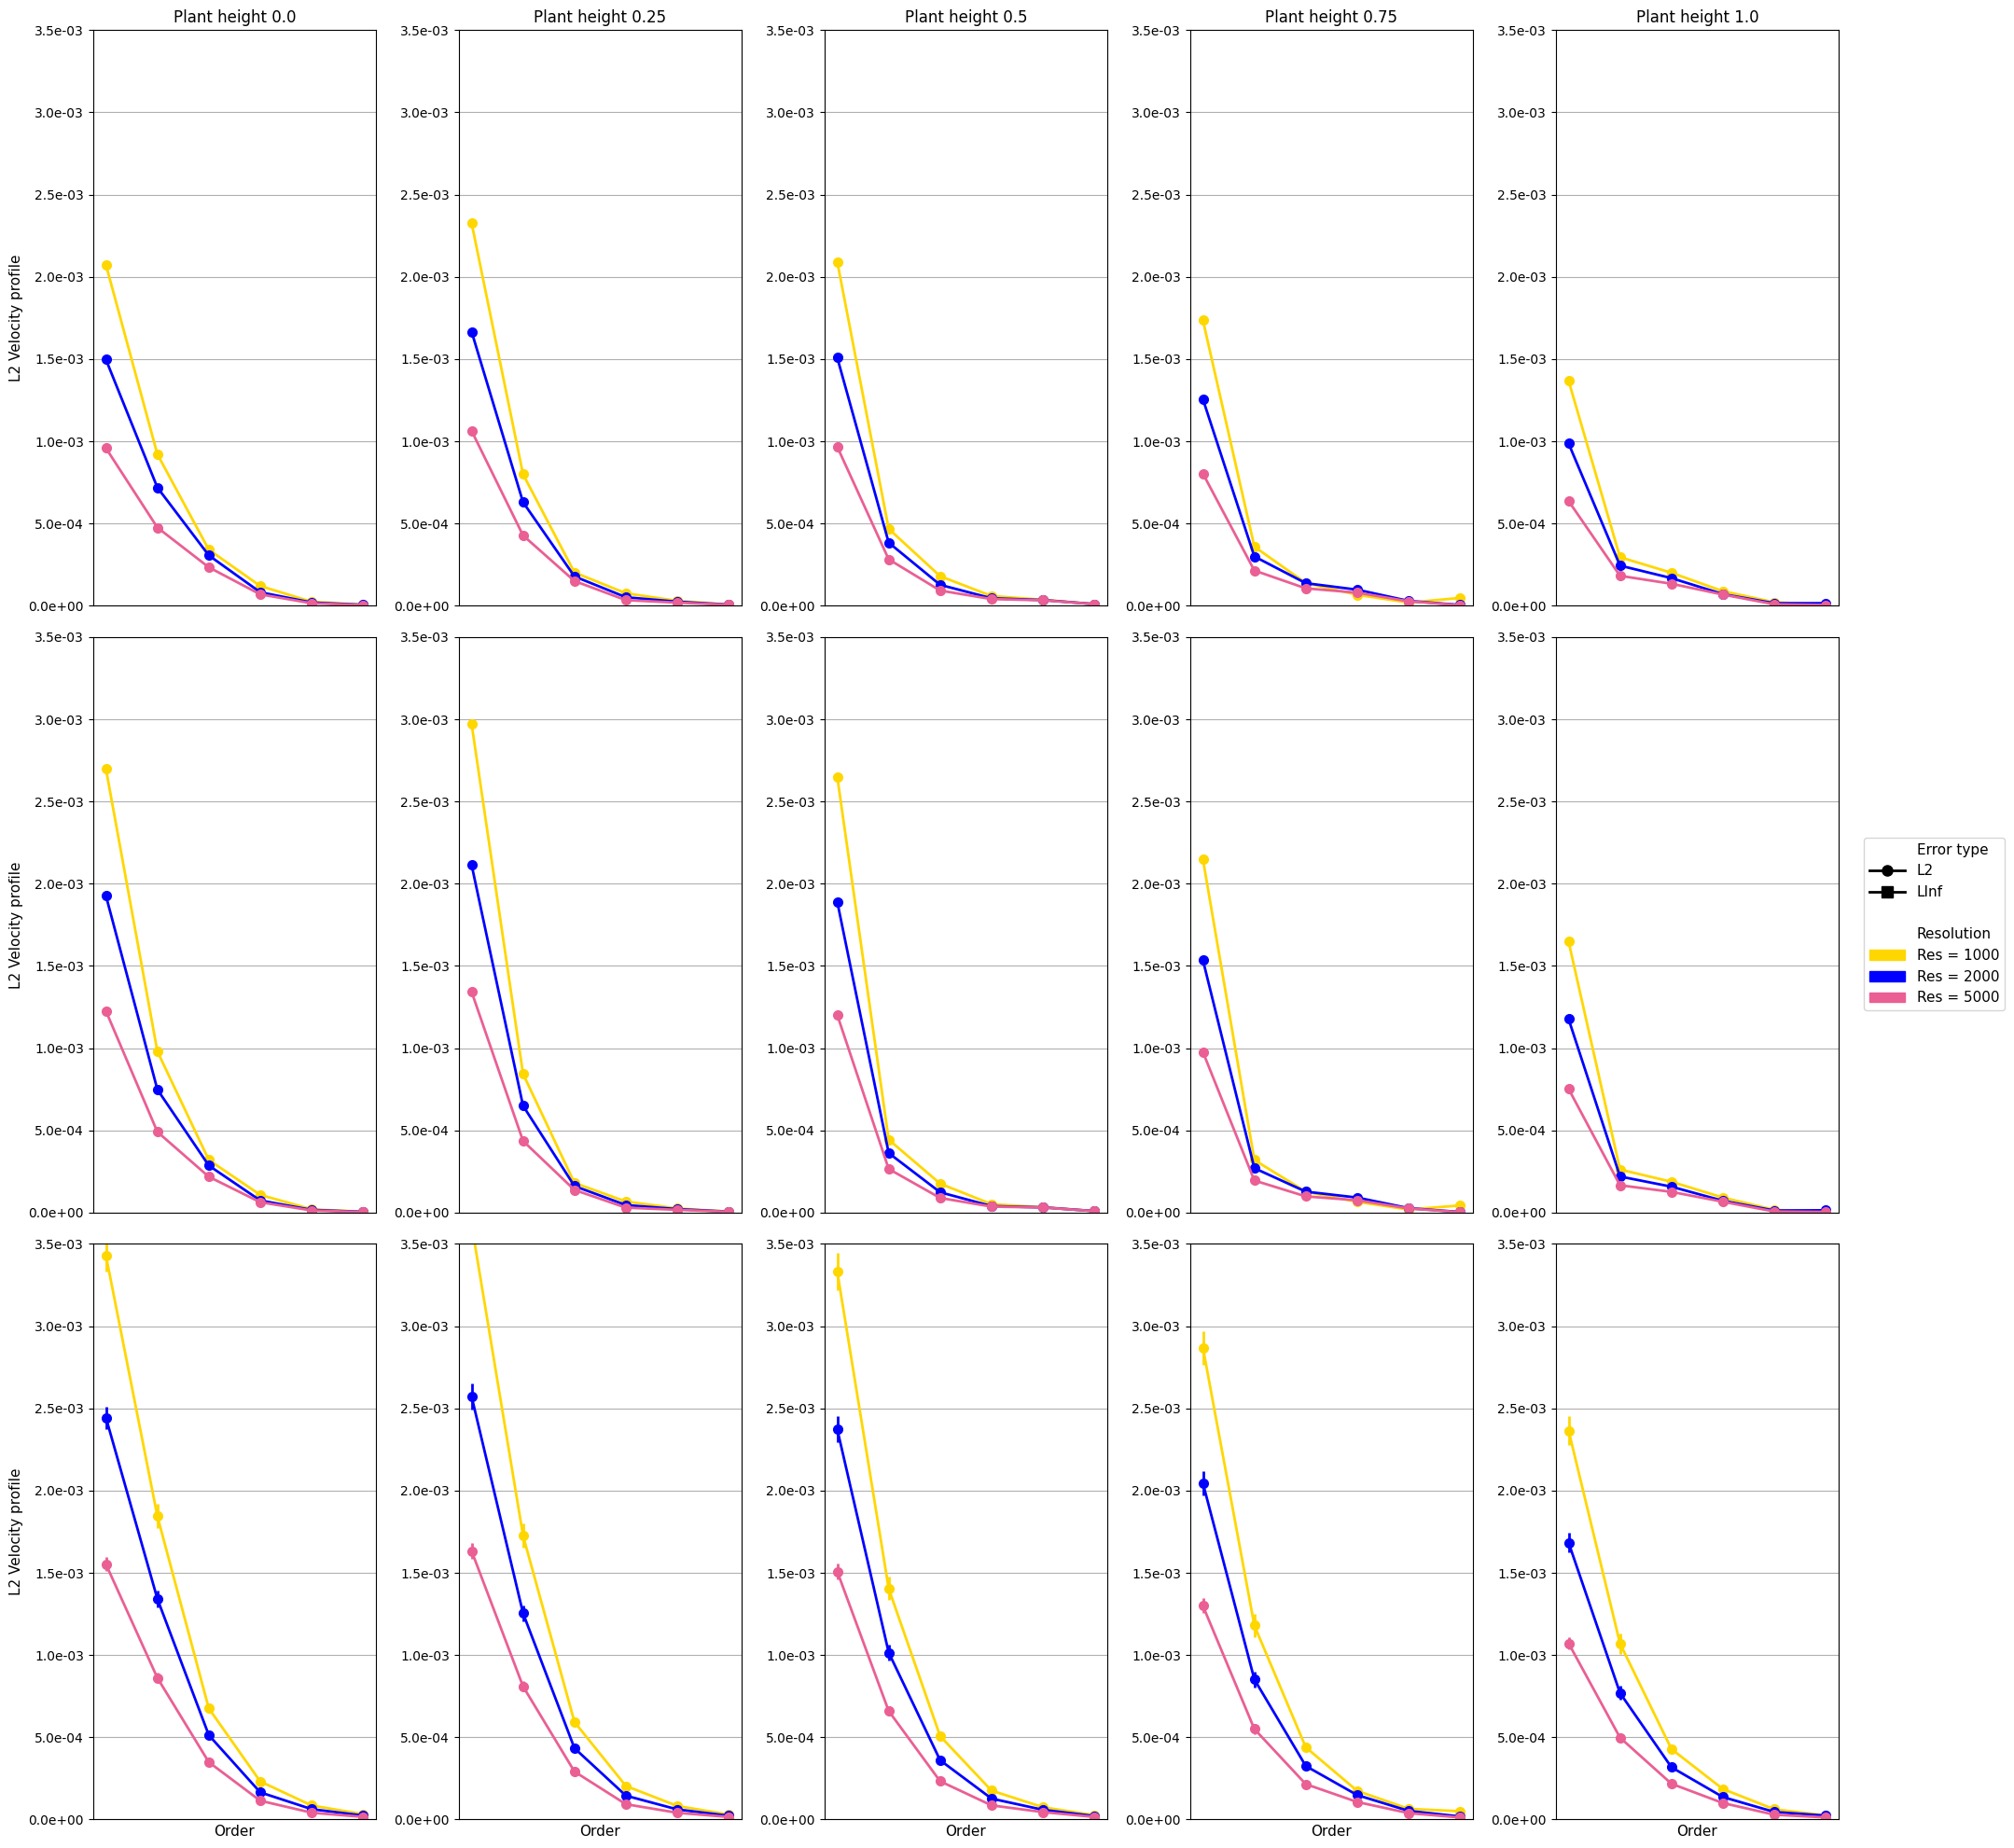

In [ ]:
resolution_list = errors["Resolution"].unique()
plant_h_list = errors["Plant Height"].unique()        

# Error vs resolution
fig, axs = plt.subplots(3, 5, figsize=(20,20), sharex=True)

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
})
error_types = ["L2 "]
for i, height in enumerate(plant_h_list):

    for resolution in resolution_list:

        mask = (errors["Plant Height"] == height) & (errors["Resolution"] == resolution)

        for j, error_type in enumerate(error_types):
            axs[0+3*j, i].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Water Height"],
                        linestyle='-',
                        marker=marker_map[error_type], 
                        color=color_map[resolution]
                    )

            axs[1+3*j, i].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Average Velocity"],
                        linestyle='-',
                        marker=marker_map[error_type], 
                        color=color_map[resolution]
                    )

            axs[2+3*j, i].errorbar(errors.loc[mask,"Order"], errors.loc[mask, error_type+"U profile"],
                        yerr=errors.loc[mask, "L2 std U profile"],
                        linestyle='-',
                        marker=marker_map[error_type], 
                        color=color_map[resolution]
                    )

for ax,h in zip(axs[0,:],plant_h_list): ax.set_title(f"Plant height {h}")
# for error_type in error_types:
#     for title in zip(error_types,quantity):
#TODO: I forgot what this was for hahaha

for ax, error_type, quantity in product(axs[:,0], error_types, quantities_list):
    ax.set_ylabel(error_type+quantity)
for ax in axs[-1,:]: ax.set_xlabel("Order")# of the polynomial")
for ax in axs[:3,:].flatten(): ax.set_ylim(0, 3.5e-3)
for ax in axs[3:,:].flatten(): ax.set_ylim(0, 4e-1)


for ax in axs.flatten():
    ax.grid()
    ax.grid(which="minor", color="0.9")
    ax.set_xticks(range(0,6))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: '{:.1e}'.format(x)))
create_legend_order_vs_error(fig)
fig.tight_layout()

### Order vs Time for each res

#### Individual

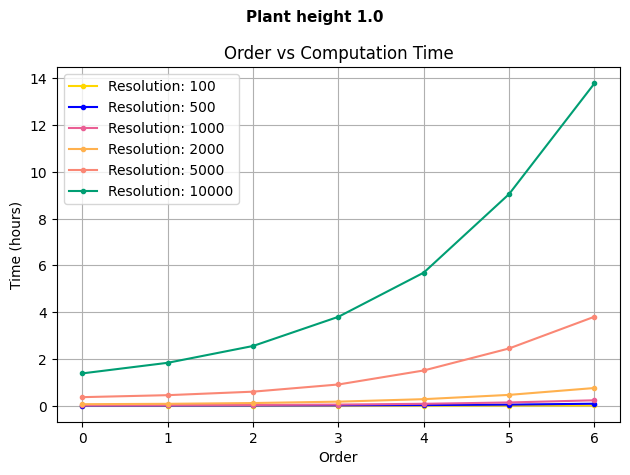

In [91]:
fig, axs = plt.subplots(1)

for resolution in resolution_list:

    mask = (data_time["Plant Height"] == 1.0) & (data_time["Resolution"] == resolution)
    
    axs.plot(data_time.loc[mask,"Order"], data_time.loc[mask, "Time"] / 3600,
                linestyle='-',
                color=color_map[resolution],
                marker=marker_map[error_type],
                label=f"Resolution: {int(resolution)}")

axs.set_title("Order vs Computation Time")
axs.set_xlabel("Order")
axs.set_ylabel("Time (hours)")
axs.legend()
axs.grid()

fig.suptitle("Plant height 1.0", fontsize=11, fontweight='bold')
fig.tight_layout()

plt.show()

#### combined Individual and commulative

TypeError: 'Axes' object is not subscriptable

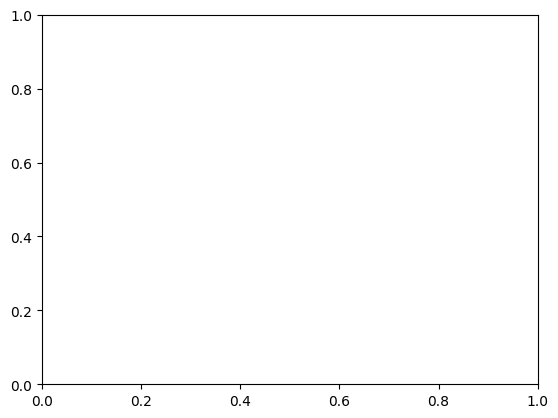

In [ ]:
fig, axs = plt.subplots(1,2)

cummulative_time = []
for resolution in resolution_list:

    mask = (data_time["Plant Height"] == 1.0) & (data_time["Resolution"] == resolution)
    
    axs[0].plot(data_time.loc[mask,"Order"], data_time.loc[mask, "Time"] / 3600,
                linestyle='-',
                color=color_map[resolution],
                marker=marker_map[error_type],
                label=f"Resolution: {int(resolution)}")

    cummulative_time.append(data_time.loc[mask, "Time"].sum() / 3600)

axs[1].plot(resolution_list, cummulative_time,
                linestyle='-',
                marker=".",
                color="black")

axs[0].set_title("Order vs Computation Time")
axs[0].set_xlabel("Order")
axs[0].set_ylabel("Time (hours)")

axs[1].set_title("Total Computation Time per resolution")
axs[1].set_xlabel('Resolution')
axs[1].set_ylabel("Cummulative Time (hours)")
axs[0].legend()
for ax in axs.flatten(): 
    ax.grid()

fig.suptitle("Plant height 1.0", fontsize=11, fontweight='bold')
fig.tight_layout()

plt.show()

### Dunno

In [21]:
mask_3 = mask_func(velocity_profile, 3, 5000, height)
resolution=5000

velocity_profile.loc[mask_3,"0.0":].reset_index(drop=1).loc[resolution//2]

0.0                     0.053711
0.010101010101010102    0.061764
0.020202020202020204    0.069671
0.030303030303030304    0.077433
0.04040404040404041     0.085051
                          ...   
0.9595959595959597      0.364944
0.9696969696969697      0.365540
0.9797979797979799      0.366126
0.98989898989899        0.366704
1.0                     0.367277
Name: 2500, Length: 100, dtype: float64

In [34]:
def create_legend_velocity_profiles(fig):
    """ 
    Creates a single legend where it specifies:
        - What marker is associated to L2 norm and LInf
        - What color is linked to what resolution
    """
    marker_handles = []
    for order, marker in marker_map.items():
        handle = mlines.Line2D( [], [],
                                marker=marker,
                                markersize=8, color='black',
                                label=f"{int(order)}"
                            )
        marker_handles.append(handle)

    color_handles = []
    for height, color in color_map.items():
        handle = mpatches.Patch(color=color, label=f"Res = {int(res)}")
        color_handles.append(handle)

    # A blank line as a spacer
    blank = mlines.Line2D([], [], color='none', label='')  

    fig.legend(
        handles=[
            mlines.Line2D([], [], color='none', label='Order'),   # header
            *marker_handles,
            blank,                                                       
            mlines.Line2D([], [], color='none', label='O'),    # header
            *color_handles,
        ],
        loc='center left',    # places legend to the right of all subplots
        bbox_to_anchor = (1.0, 0.5),
        frameon=True,
        fontsize=11,
        handlelength=2.5,)

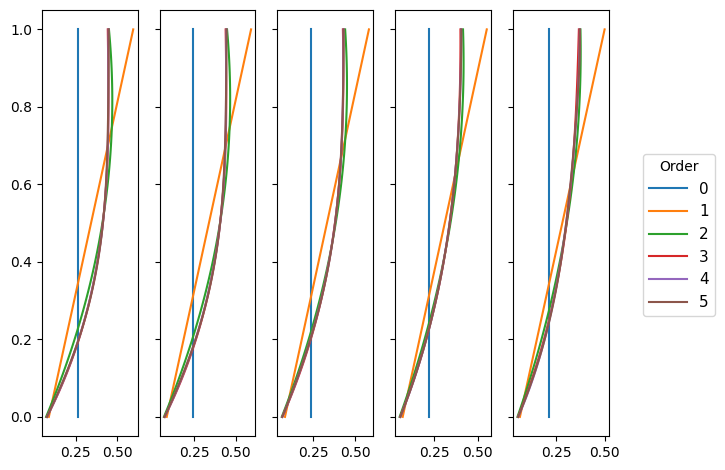

In [37]:
def mask_func(array, order, resolution, height):
    return (array["Order"] == order) & (array["Resolution"]==resolution) & (array["Plant Height"]==height)

z_values = np.linspace(0,1,100)

fig, axs = plt.subplots(1,5, tight_layout=True, sharey=1)

for i,height in enumerate(plant_h_list):
    for order in range(6):
        mask = mask_func(velocity_profile, order, 5000, height)

        if i==4:
            axs[i].plot(velocity_profile.loc[mask,"0.0":].reset_index(drop=1).loc[5000//2], z_values,
                    label=f"{order}")
        else:
            axs[i].plot(velocity_profile.loc[mask,"0.0":].reset_index(drop=1).loc[5000//2], z_values)


fig.legend(title="Order",
        loc='center left',
        bbox_to_anchor = (1.0, 0.5),
        frameon=True,
        fontsize=11,
        handlelength=2.5)


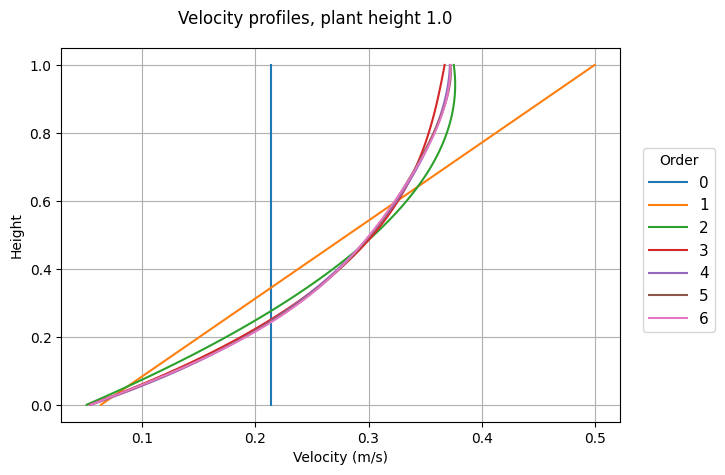

In [78]:
def mask_func(array, order, resolution, height):
    return (array["Order"] == order) & (array["Resolution"]==resolution) & (array["Plant Height"]==height)

z_values = np.linspace(0,1,100)

fig, axs = plt.subplots(1, tight_layout=True, sharey=1)

for order in range(7):
    mask = mask_func(velocity_profile, order, 5000, 1.0)

    axs.plot(velocity_profile.loc[mask,"0.0":].reset_index(drop=1).loc[5000//2], z_values,
                label=f"{order}")
axs.grid()
axs.set_xlabel("Velocity (m/s)")
axs.set_ylabel("Height")
fig.suptitle("Velocity profiles, plant height 1.0")
fig.legend(title="Order",
        loc='center left',
        bbox_to_anchor = (1.0, 0.5),
        frameon=True,
        fontsize=11,
        handlelength=2.5)

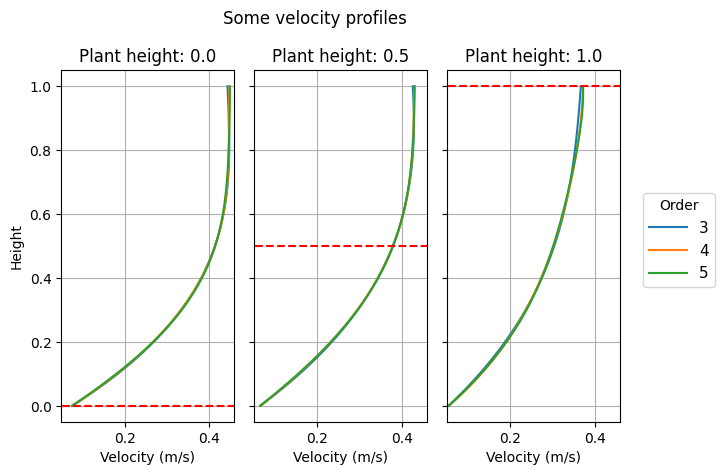

In [77]:
def mask_func(array, order, resolution, height):
    return (array["Order"] == order) & (array["Resolution"]==resolution) & (array["Plant Height"]==height)

z_values = np.linspace(0,1,100)

fig, axs = plt.subplots(1,3, tight_layout=True, sharey=1)

color_map = {order: f"C{i}" for i, order in enumerate(range(3, 6))}
# C0, C1, C2 are matplotlib's default color cycle colors

for i,height in enumerate([0.0, 0.5, 1.0]):
    for order in range(3, 6):
        mask = mask_func(velocity_profile, order, 5000, height)
        label = str(order) if height == 1.0 else None
        axs[i-3].plot(
            velocity_profile.loc[mask, "0.0":].reset_index(drop=1).loc[5000//2],
            z_values,
            color=color_map[order],   # ← explicit color
            label=label
        )
line_x = np.linspace(0,1,10)
axs[0].plot(line_x, np.full_like(line_x, 0), 'r--')
axs[1].plot(line_x, np.full_like(line_x, 0.5), 'r--')
axs[2].plot(line_x, np.full_like(line_x, 1), 'r--')

for ax in axs: ax.set_xlim(0.05,0.46)
axs[0].set_title(f"Plant height: 0.0")
axs[1].set_title(f"Plant height: 0.5")
axs[2].set_title(f"Plant height: 1.0")
for ax in axs: ax.grid()
for ax in axs: ax.set_xlabel("Velocity (m/s)")
axs[0].set_ylabel("Height")
fig.suptitle("Some velocity profiles")
fig.legend(title="Order",
        loc='center left',
        bbox_to_anchor = (1.0, 0.5),
        frameon=True,
        fontsize=11,
        handlelength=2.5)

In [17]:
Average error

# fig, axs = plt.subplots(1,5, tight_layout=True)
# for i, height in enumerate(plant_h_list):

#     for resolution in resolution_list:

#         mask = errors["Resolu"]
#         axs[i] = plt.plot(errors["Order"])



SyntaxError: invalid syntax (2279482582.py, line 1)